# 🏦 Loan Eligibility Prediction using Machine Learning

## 📌 Project Overview

Pemberian pinjaman merupakan salah satu layanan utama pada industri keuangan. Namun, setiap pengajuan pinjaman memiliki tingkat risiko yang berbeda sehingga diperlukan proses penilaian kelayakan (loan eligibility assessment) sebelum pinjaman disetujui.

Pada project ini, dibangun sebuah model **Machine Learning Classification** untuk memprediksi apakah seorang pemohon pinjaman berpotensi memperoleh persetujuan pinjaman berdasarkan karakteristik demografi, kondisi finansial, riwayat kredit, dan informasi pinjaman yang diajukan.

Dataset yang digunakan merupakan **Loan Approval Classification Dataset** dari Kaggle yang berisi informasi mengenai profil peminjam beserta status persetujuan pinjaman.

---

## 🎯 Business Problem

Proses evaluasi pengajuan pinjaman secara manual memerlukan waktu yang cukup lama dan berpotensi menghasilkan keputusan yang tidak konsisten antar analis kredit. Hal tersebut dapat menyebabkan:

- meningkatnya risiko kredit macet,
- proses persetujuan yang lambat,
- biaya operasional yang lebih tinggi.

Dengan memanfaatkan Machine Learning, perusahaan dapat membangun sistem pendukung keputusan yang mampu membantu analis kredit melakukan proses screening awal terhadap calon peminjam.

---

## 🎯 Project Objectives

Project ini bertujuan untuk:

- Memahami karakteristik data peminjam melalui Exploratory Data Analysis (EDA).
- Mengidentifikasi faktor-faktor yang memengaruhi persetujuan pinjaman.
- Membangun model Machine Learning untuk memprediksi status persetujuan pinjaman.
- Mengevaluasi performa model menggunakan berbagai metrik klasifikasi.
- Memberikan insight bisnis yang dapat digunakan sebagai dasar pengambilan keputusan.

---

## 📊 Dataset Information

- **Dataset** : Loan Approval Classification Dataset
- **Source** : Kaggle
- **Target Variable** : `loan_status`

---

## 🛠 Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

# 🎯 Tujuan

# Tujuan
- Melakukan analisis data
- Membangun model
- Mengevaluasi performa model

# 📦 Import Library

Bagian ini memuat seluruh library yang digunakan.

In [12]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Visualization Style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

# Pandas Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Library berhasil diimpor.")

Library berhasil diimpor.


# 📂 Data Loading

Dataset yang digunakan pada proyek ini adalah **Loan Approval Classification Dataset** yang diperoleh dari Kaggle.

Tahap ini bertujuan untuk memuat dataset ke dalam DataFrame Pandas sehingga dapat dilakukan proses eksplorasi, pembersihan data, dan pembangunan model Machine Learning.

In [13]:
df = pd.read_csv("loan_data.csv")

print("=" * 50)
print("Dataset Successfully Loaded")
print("=" * 50)

print(f"Jumlah Baris  : {df.shape[0]:,}")
print(f"Jumlah Kolom  : {df.shape[1]}")

df.head()


Dataset Successfully Loaded
Jumlah Baris  : 45,000
Jumlah Kolom  : 14


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.00,female,Master,71948.00,0,RENT,35000.00,PERSONAL,16.02,0.49,3.00,561,No,1
1,21.00,female,High School,12282.00,0,OWN,1000.00,EDUCATION,11.14,0.08,2.00,504,Yes,0
2,25.00,female,High School,12438.00,3,MORTGAGE,5500.00,MEDICAL,12.87,0.44,3.00,635,No,1
3,23.00,female,Bachelor,79753.00,0,RENT,35000.00,MEDICAL,15.23,0.44,2.00,675,No,1
4,24.00,male,Master,66135.00,1,RENT,35000.00,MEDICAL,14.27,0.53,4.00,586,No,1


# 🔍 Data Understanding


Sebelum melakukan analisis lebih lanjut, penting untuk memahami struktur dataset yang digunakan.

Tahap ini bertujuan untuk:

- Mengetahui ukuran dataset.
- Mengidentifikasi tipe data setiap variabel.
- Memahami karakteristik fitur numerik dan kategorikal.
- Mengidentifikasi jumlah nilai unik pada setiap fitur.

Pemahaman awal terhadap dataset akan membantu menentukan langkah preprocessing dan pemodelan yang tepat.

In [14]:
print("=" * 50)
print("Dataset Overview")
print("=" * 50)

overview = pd.DataFrame({
    "Information": [
        "Number of Rows",
        "Number of Columns",
        "Numerical Features",
        "Categorical Features",
        "Target Variable"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.select_dtypes(include=np.number).shape[1],
        df.select_dtypes(include="object").shape[1],
        "loan_status"
    ]
})

overview

Dataset Overview


,Information,Value
0,Number of Rows,45000
1,Number of Columns,14
2,Numerical Features,9
3,Categorical Features,5
4,Target Variable,loan_status


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.00,27.76,6.05,20.00,24.00,26.00,30.00,144.00
person_income,45000.00,80319.05,80422.50,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.00,5.41,6.06,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.00,9583.16,6314.89,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.00,11.01,2.98,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.00,0.14,0.09,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.00,5.87,3.88,2.00,3.00,4.00,8.00,30.00
credit_score,45000.00,632.61,50.44,390.00,601.00,640.00,670.00,850.00
loan_status,45000.00,0.22,0.42,0.00,0.00,0.00,0.00,1.00


In [17]:
df.describe(include="object").T

,count,unique,top,freq
person_gender,45000,2,male,24841
person_education,45000,5,Bachelor,13399
person_home_ownership,45000,4,RENT,23443
loan_intent,45000,6,EDUCATION,9153
previous_loan_defaults_on_file,45000,2,Yes,22858


In [18]:
# Data Types & Unique Values

summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

summary

,Data Type,Unique Values,Missing Values
person_age,float64,60,0
person_gender,object,2,0
person_education,object,5,0
person_income,float64,33989,0
person_emp_exp,int64,63,0
person_home_ownership,object,4,0
loan_amnt,float64,4483,0
loan_intent,object,6,0
loan_int_rate,float64,1302,0
loan_percent_income,float64,64,0


## Insight

Berdasarkan hasil eksplorasi awal, dataset terdiri dari **45.000 observasi** dengan **14 variabel**, yang mencakup informasi demografi peminjam, kondisi finansial, riwayat kredit, dan karakteristik pinjaman.

Dataset memiliki kombinasi fitur numerik dan kategorikal yang sesuai untuk membangun model klasifikasi. Selain itu, tahap ini memberikan gambaran awal mengenai struktur data sehingga dapat menjadi dasar dalam menentukan strategi preprocessing, seperti penanganan missing values, encoding fitur kategorikal, dan normalisasi fitur numerik pada tahap selanjutnya.

# 🧹 Missing Value Analysis
Sebelum melakukan Exploratory Data Analysis (EDA) dan membangun model Machine Learning, penting untuk memastikan kualitas data.

Salah satu langkah awal adalah memeriksa keberadaan **missing values** pada setiap fitur. Nilai yang hilang dapat memengaruhi hasil analisis maupun performa model apabila tidak ditangani dengan tepat.

Pada tahap ini akan dilakukan:

- Mengidentifikasi jumlah missing values pada setiap fitur.
- Menghitung persentase missing values.
- Menentukan apakah diperlukan proses imputasi pada tahap preprocessing.

In [20]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

missing_values

,Missing Values,Percentage (%)
person_age,0,0.00
person_gender,0,0.00
person_education,0,0.00
person_income,0,0.00
person_emp_exp,0,0.00
person_home_ownership,0,0.00
loan_amnt,0,0.00
loan_intent,0,0.00
loan_int_rate,0,0.00
loan_percent_income,0,0.00


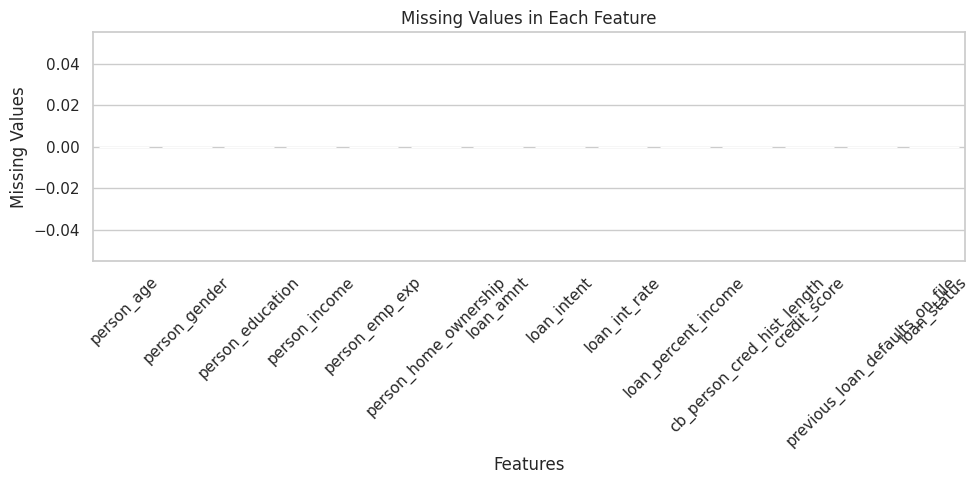

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=missing_values.reset_index(),
    x="index",
    y="Missing Values",
    color="steelblue"
)

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Missing Values")
plt.title("Missing Values in Each Feature")

plt.tight_layout()
plt.show()

## 💡 Insight

Hasil pemeriksaan menunjukkan bahwa dataset **tidak memiliki missing values** pada seluruh fitur. Hal ini menunjukkan kualitas data yang baik dan memungkinkan proses analisis dilanjutkan tanpa memerlukan teknik imputasi.

Dengan demikian, tahap preprocessing selanjutnya dapat difokuskan pada transformasi fitur dan persiapan data untuk proses pemodelan.

In [5]:
duplicate = df.duplicated().sum()

print(f"Jumlah data duplikat : {duplicate}")

Jumlah data duplikat : 0


In [22]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": [df[col].nunique() for col in df.columns]
})

dtype_df

,Column,Data Type,Unique Values
0,person_age,float64,60
1,person_gender,object,2
2,person_education,object,5
3,person_income,float64,33989
4,person_emp_exp,int64,63
5,person_home_ownership,object,4
6,loan_amnt,float64,4483
7,loan_intent,object,6
8,loan_int_rate,float64,1302
9,loan_percent_income,float64,64


Pemeriksaan tipe data memastikan bahwa setiap variabel telah direpresentasikan sesuai karakteristiknya. Variabel kategorikal nantinya memerlukan proses encoding sebelum digunakan pada model Machine Learning.

# 📊 EDA - Distribusi Target

Tahap ini bertujuan untuk memahami distribusi variabel target (`loan_status`).

Distribusi target penting untuk diketahui karena akan memengaruhi strategi pemodelan dan pemilihan metrik evaluasi. Dataset dengan distribusi kelas yang tidak seimbang (imbalanced) sering kali memerlukan pendekatan khusus agar model tidak bias terhadap kelas mayoritas.

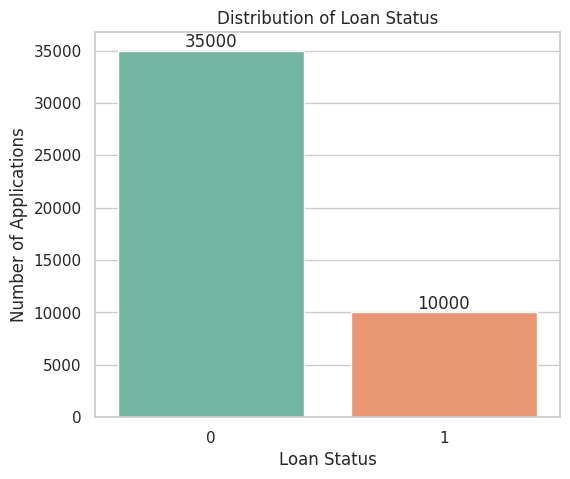

,Percentage (%)
loan_status,
0,77.78
1,22.22


In [23]:
target_count = df["loan_status"].value_counts()

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="loan_status",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

display(
    (df["loan_status"]
       .value_counts(normalize=True)
       .mul(100)
       .round(2)
       .rename("Percentage (%)"))
)

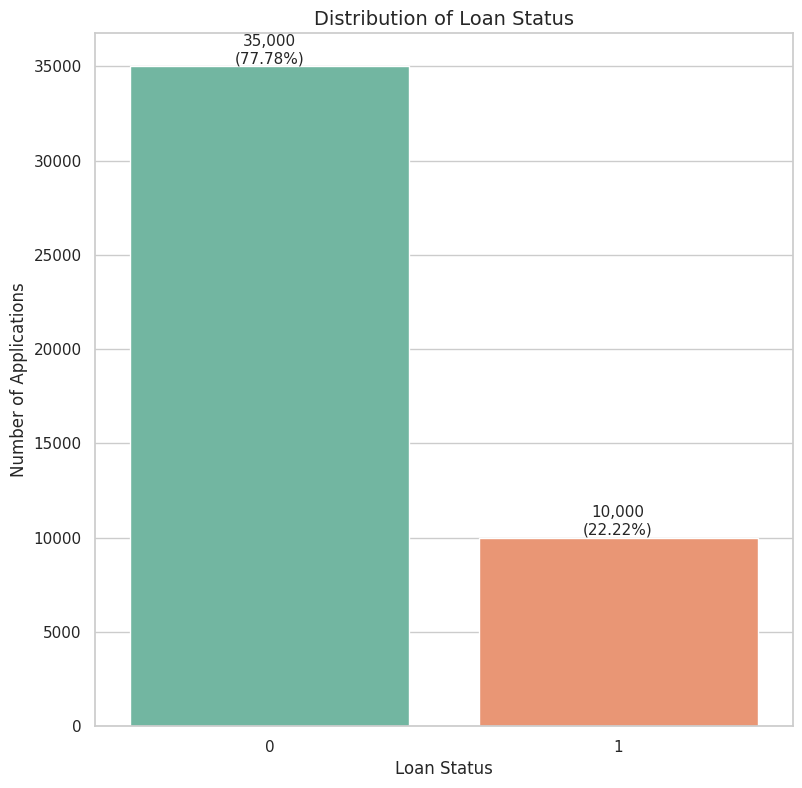

In [35]:
plt.figure(figsize=(9,9))

ax = sns.countplot(
    data=df,
    x="loan_status",
    palette="Set2"
)

total = len(df)

for p in ax.patches:

    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(
        f"{count:,}\n({percentage:.2f}%)",
        (p.get_x() + p.get_width()/2, count),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Distribution of Loan Status", fontsize=14)
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

In [32]:
label_mapping = {
    0: "Rejected",
    1: "Approved"
}

df_plot = df.copy()
df_plot["loan_status"] = df_plot["loan_status"].map(label_mapping)

**Business Insight**


Distribusi target menunjukkan proporsi antara pengajuan pinjaman yang disetujui dan yang tidak.

Apabila kedua kelas memiliki proporsi yang relatif seimbang, model klasifikasi dapat dilatih secara langsung tanpa memerlukan teknik penanganan data imbalance. Sebaliknya, apabila salah satu kelas jauh lebih dominan, maka metrik seperti Precision, Recall, dan F1-Score menjadi lebih penting dibandingkan hanya mengandalkan Accuracy.

# 📈 EDA - Variabel Numerik

Analisis terhadap variabel numerik bertujuan untuk memahami karakteristik distribusi data, penyebaran nilai, serta mendeteksi keberadaan outlier.

Pada tahap ini digunakan dua jenis visualisasi:

- **Histogram**, untuk melihat bentuk distribusi setiap variabel.
- **Boxplot**, untuk mengidentifikasi penyebaran data dan potensi outlier.

In [36]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.00,27.76,6.05,20.00,24.00,26.00,30.00,144.00
person_income,45000.00,80319.05,80422.50,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.00,5.41,6.06,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.00,9583.16,6314.89,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.00,11.01,2.98,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.00,0.14,0.09,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.00,5.87,3.88,2.00,3.00,4.00,8.00,30.00
credit_score,45000.00,632.61,50.44,390.00,601.00,640.00,670.00,850.00
loan_status,45000.00,0.22,0.42,0.00,0.00,0.00,0.00,1.00


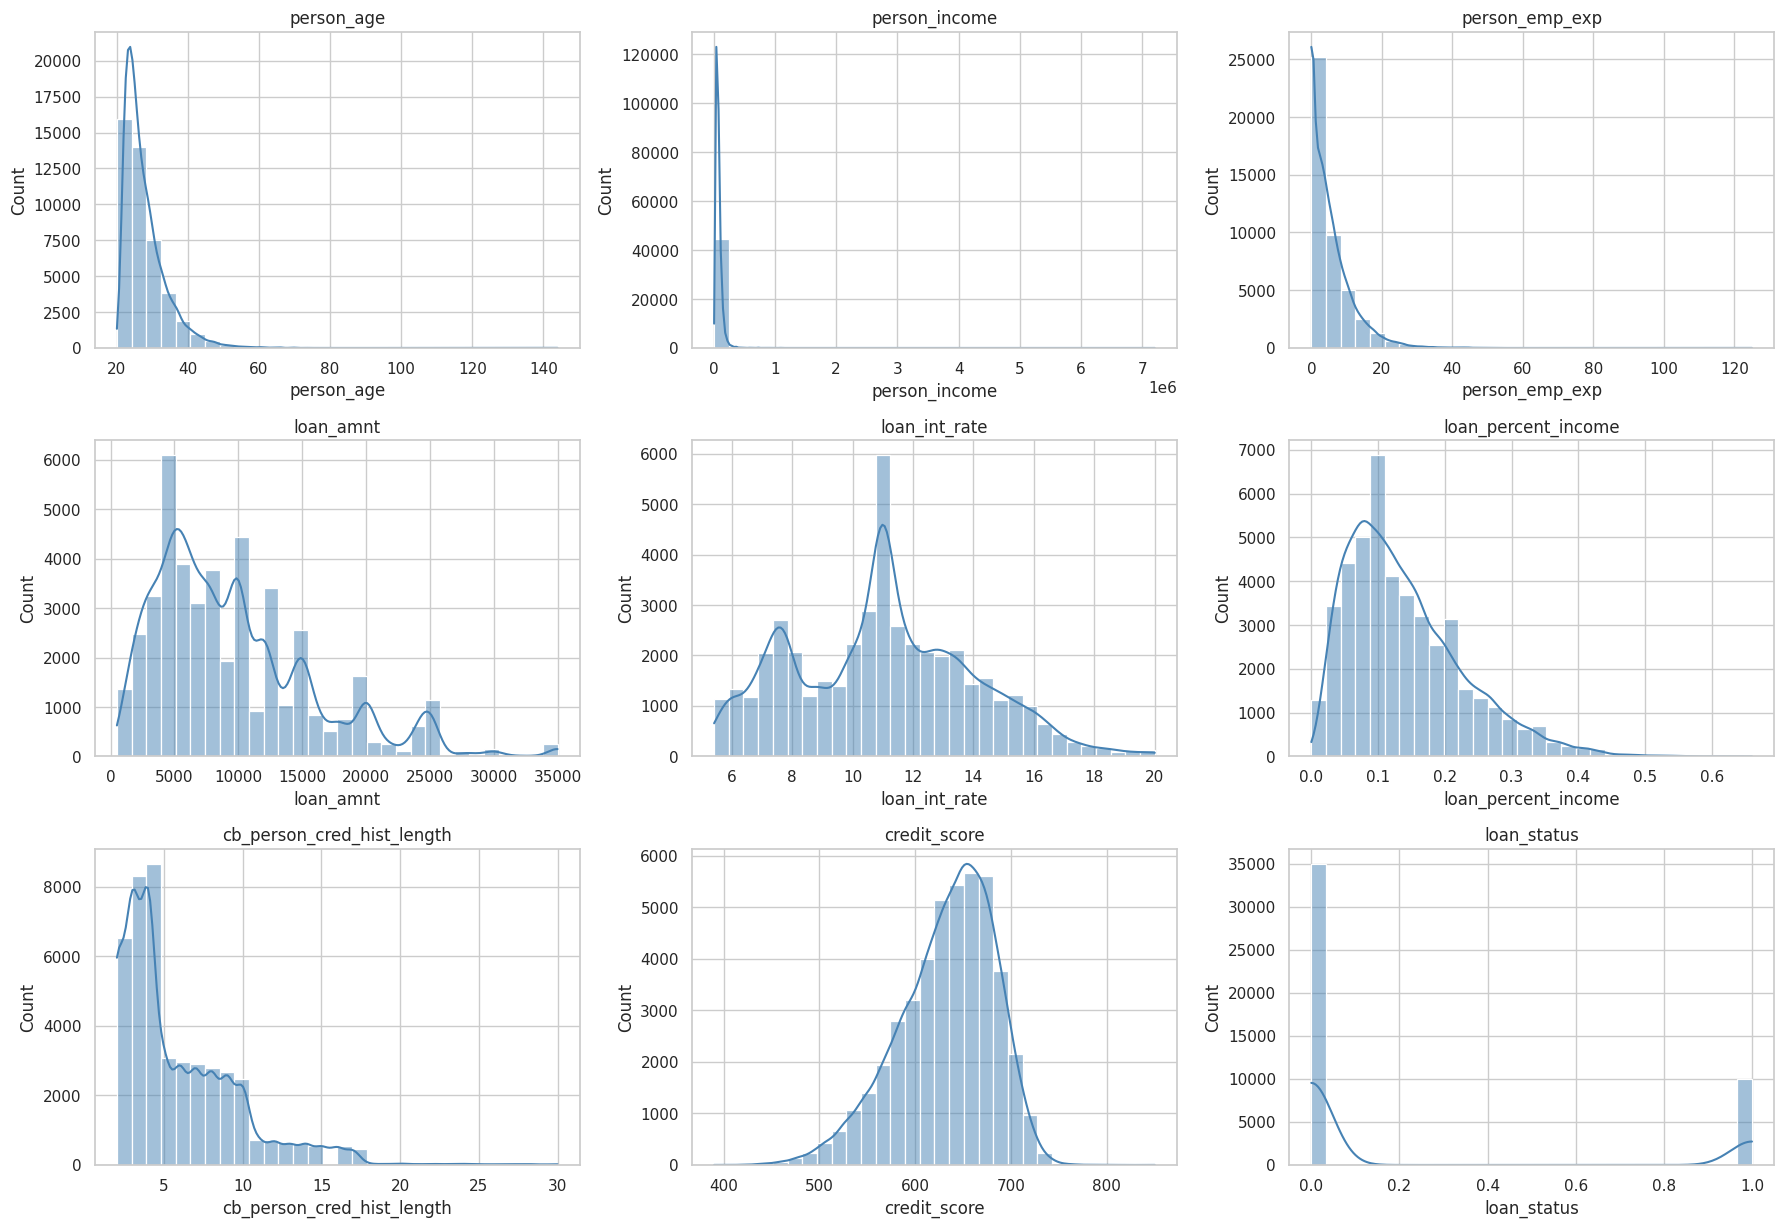

In [24]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

fig, axes = plt.subplots(4, 3, figsize=(18,16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30,
        color="steelblue",
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Distribusi setiap variabel numerik membantu mengidentifikasi karakteristik data, seperti kemencengan distribusi (skewness), keberadaan outlier, maupun rentang nilai yang sangat lebar. Informasi ini penting untuk menentukan apakah diperlukan transformasi data, normalisasi, atau penanganan outlier sebelum proses pemodelan.

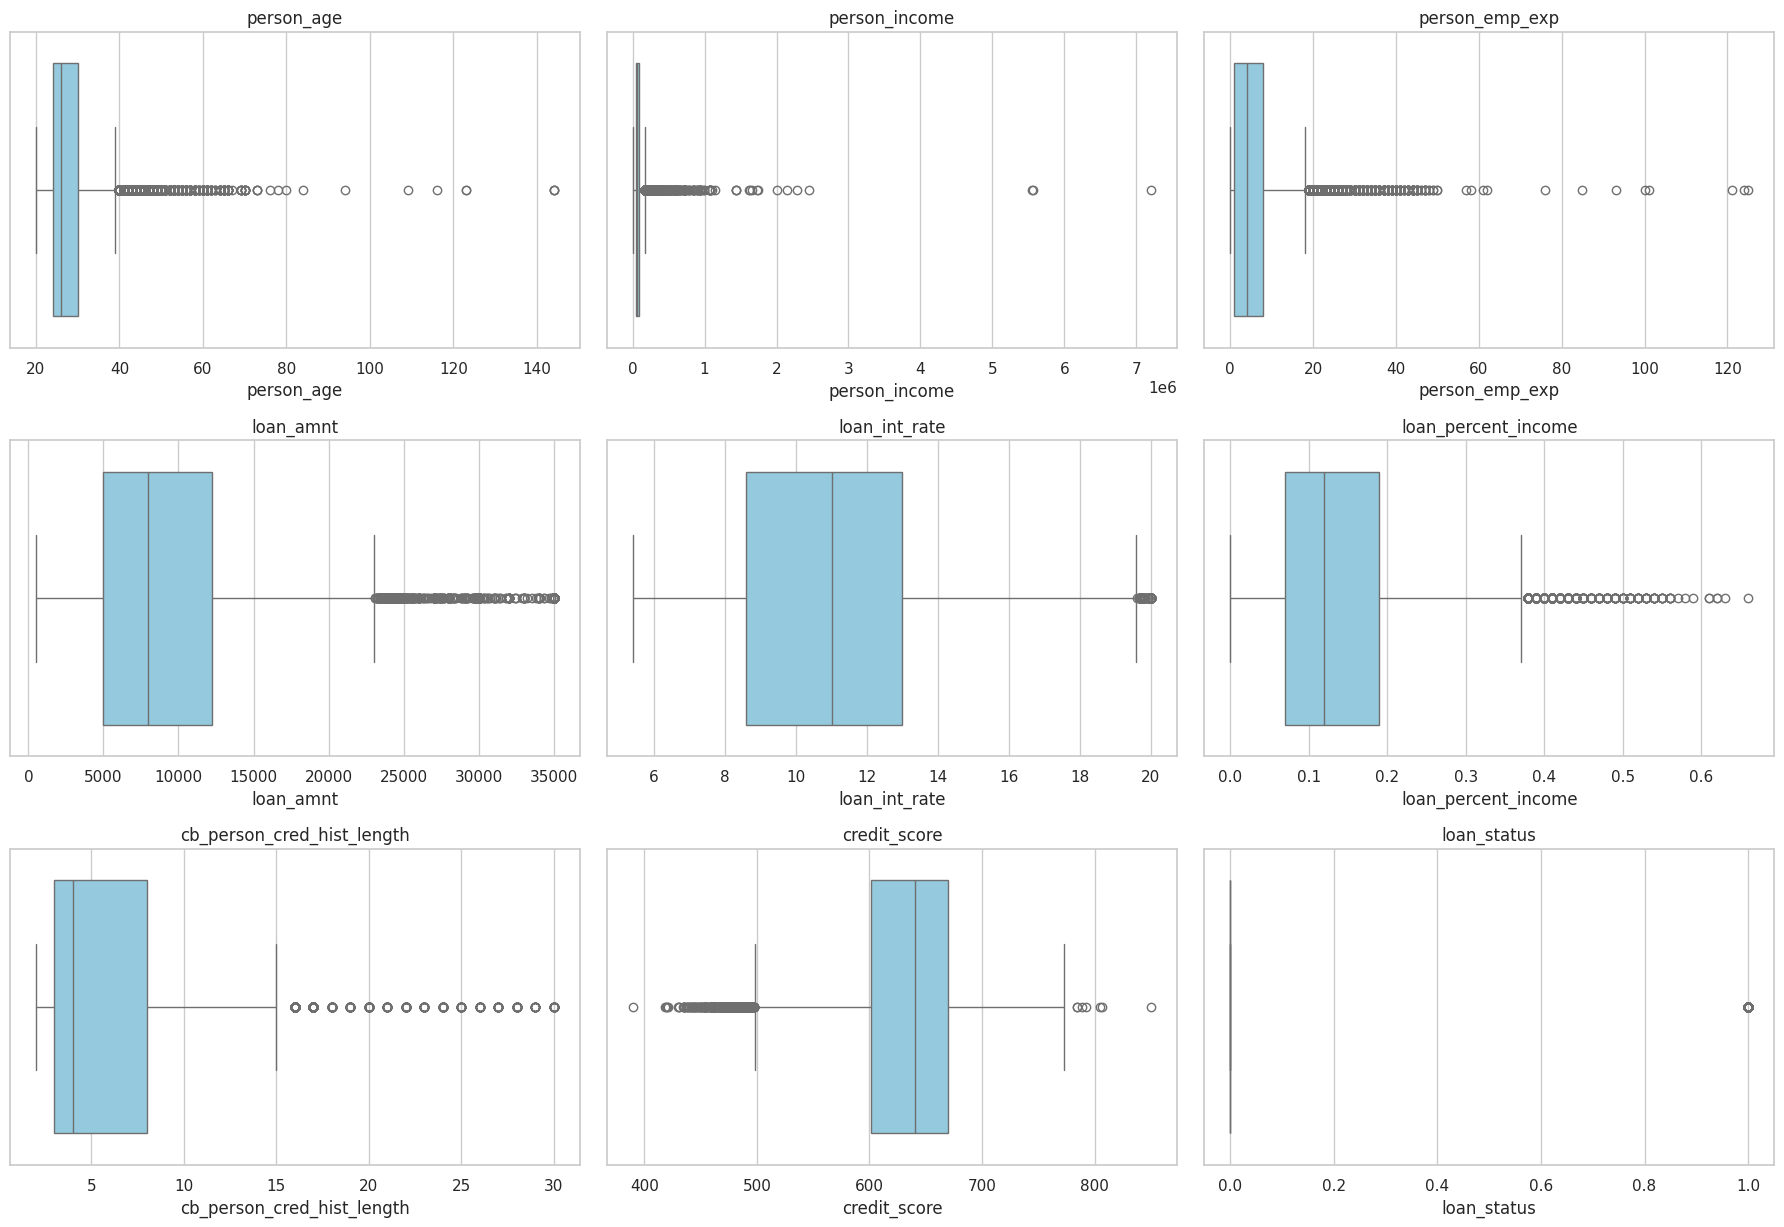

In [25]:
#  Boxplot

fig, axes = plt.subplots(4, 3, figsize=(18,16))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df[col],
        color="skyblue",
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#  EDA - Variabel Kategorikal

Analisis terhadap variabel kategorikal dilakukan untuk memahami distribusi setiap kategori pada dataset.

Visualisasi ini membantu mengidentifikasi karakteristik mayoritas pemohon pinjaman serta mendeteksi kategori dengan jumlah observasi yang sangat sedikit.

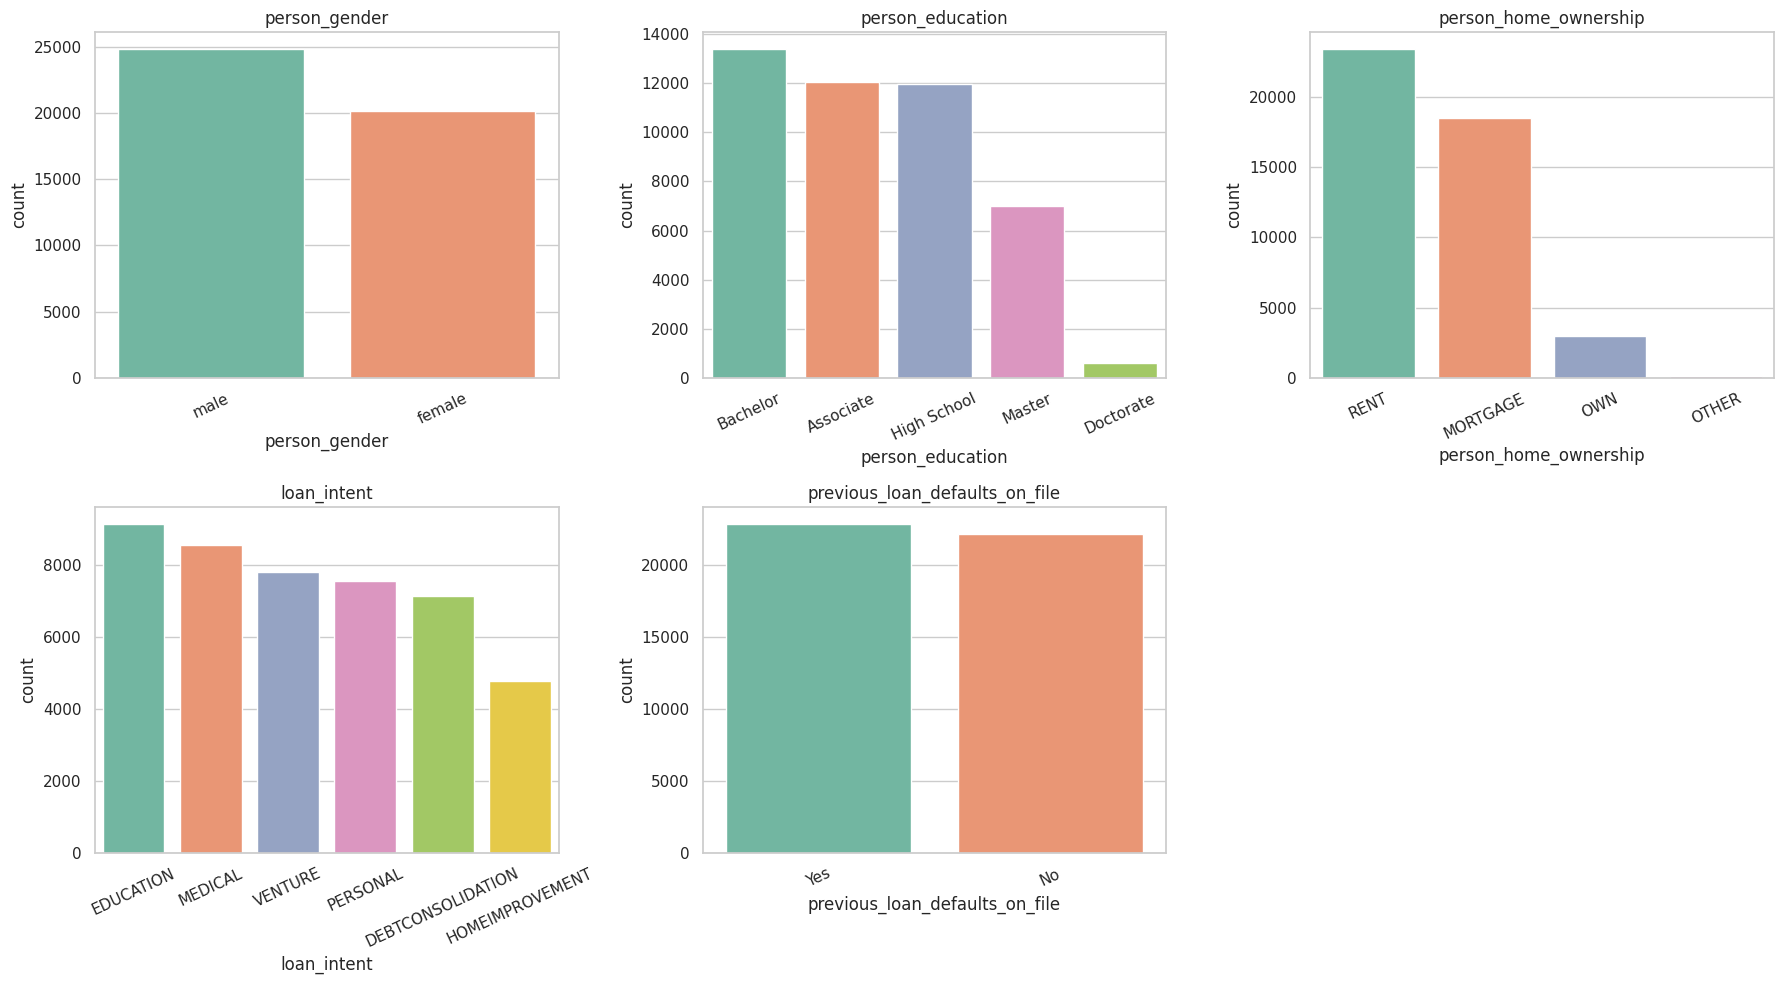

In [26]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        order=order,
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=25)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Visualisasi menunjukkan distribusi setiap variabel kategorikal pada dataset. Informasi ini memberikan gambaran mengenai karakteristik umum peminjam, seperti tingkat pendidikan, status kepemilikan rumah, tujuan pengajuan pinjaman, serta riwayat kredit sebelumnya.

Distribusi kategori yang tidak merata juga perlu diperhatikan karena dapat memengaruhi proses pembelajaran model, terutama apabila terdapat kategori dengan jumlah observasi yang sangat sedikit.

# 🔥 Correlation Analysis


Tahap ini bertujuan untuk memahami hubungan antar variabel numerik dalam dataset. Analisis korelasi membantu mengidentifikasi pola hubungan linear antar fitur, mendeteksi potensi multikolinearitas, serta memberikan gambaran awal mengenai fitur-fitur yang memiliki hubungan kuat dengan variabel lain.

Karena variabel target (`loan_status`) bertipe biner (0 = Rejected, 1 = Approved), nilai korelasinya terhadap fitur numerik juga dapat digunakan sebagai indikasi awal, meskipun tidak dapat dijadikan dasar tunggal dalam menentukan fitur yang paling penting.

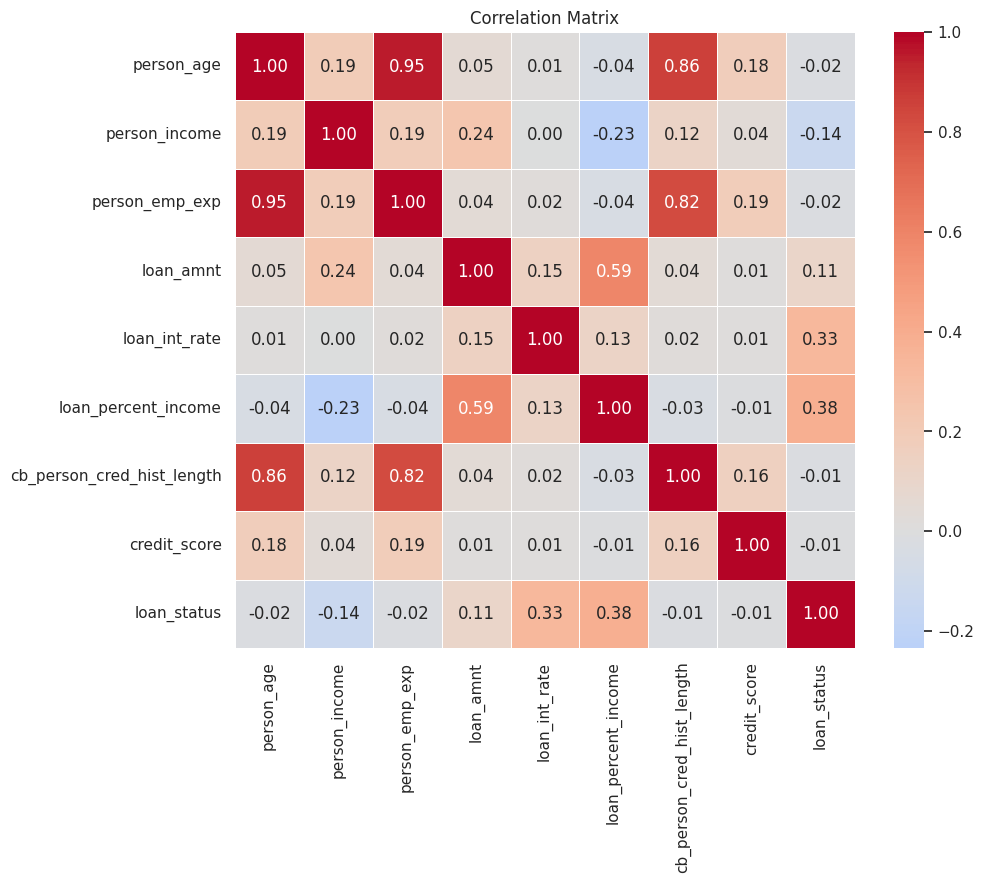

In [37]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

Visualisasi ini membantu mengidentifikasi apakah kategori tertentu memiliki kecenderungan tingkat persetujuan pinjaman yang lebih tinggi dibandingkan kategori lainnya.

Apabila ditemukan perbedaan proporsi yang cukup signifikan, maka variabel tersebut berpotensi menjadi predictor penting dalam model Machine Learning.

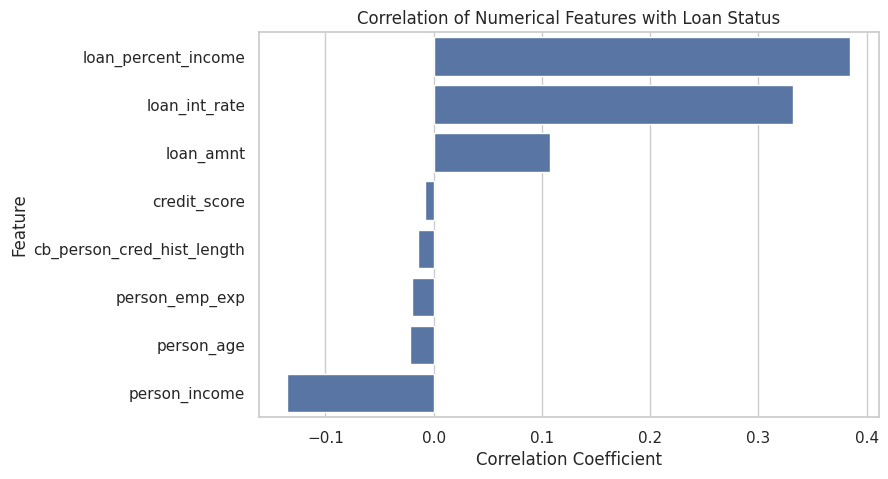

,Correlation
loan_percent_income,0.38
loan_int_rate,0.33
loan_amnt,0.11
credit_score,-0.01
cb_person_cred_hist_length,-0.01
person_emp_exp,-0.02
person_age,-0.02
person_income,-0.14


In [38]:
# Correlation with Target Variable

target_corr = (
    corr_matrix["loan_status"]
    .drop("loan_status")
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    color="#4C72B0"
)

plt.title("Correlation of Numerical Features with Loan Status")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.show()

target_corr.to_frame(name="Correlation")

## 💡 Insight

Berdasarkan hasil analisis korelasi, sebagian besar fitur numerik memiliki hubungan linear yang relatif rendah hingga sedang terhadap variabel target. Hal ini menunjukkan bahwa keputusan persetujuan pinjaman kemungkinan dipengaruhi oleh kombinasi beberapa fitur, bukan hanya satu variabel saja.

Selain itu, tidak ditemukan pasangan fitur dengan korelasi yang tinggi sehingga risiko multikolinearitas yang berlebihan relatif rendah.

# 📦 Outlier Analysis

Identifikasi outlier. Outlier merupakan observasi yang memiliki nilai jauh di luar rentang mayoritas data.

Dalam domain keuangan, keberadaan outlier tidak selalu menunjukkan kesalahan pencatatan. Sebagai contoh, peminjam dengan pendapatan yang sangat tinggi atau jumlah pinjaman yang besar masih mungkin terjadi pada kondisi nyata.

Oleh karena itu, tahap ini bertujuan untuk mengidentifikasi jumlah outlier pada setiap fitur numerik sebelum menentukan apakah diperlukan penanganan lebih lanjut.

In [39]:
# Outlier Detection using IQR

outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[
        (df[col] < lower) |
        (df[col] > upper)
    ].shape[0]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Percentage (%)": round(outlier_count/len(df)*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    by="Percentage (%)",
    ascending=False
)


,Feature,Outlier Count,Percentage (%)
8,loan_status,10000,22.22
3,loan_amnt,2348,5.22
1,person_income,2218,4.93
0,person_age,2188,4.86
2,person_emp_exp,1724,3.83
6,cb_person_cred_hist_length,1366,3.04
5,loan_percent_income,744,1.65
7,credit_score,467,1.04
4,loan_int_rate,124,0.28


Hasil identifikasi menunjukkan bahwa beberapa fitur memiliki nilai yang berada di luar rentang IQR.

Namun, karena dataset ini berasal dari domain keuangan, nilai ekstrem tersebut belum tentu merupakan kesalahan pencatatan. Pendapatan yang tinggi, pengalaman kerja yang panjang, maupun jumlah pinjaman yang besar masih dapat terjadi pada kondisi nyata.

Oleh karena itu, **outlier tidak akan langsung dihapus** agar informasi penting yang berpotensi meningkatkan kemampuan prediksi model tetap dipertahankan.

# 🧹 Data Cleaning

Tahap Data Cleaning dilakukan untuk memastikan dataset siap digunakan pada proses Feature Engineering dan pemodelan.

Berdasarkan hasil pemeriksaan sebelumnya, dataset tidak memiliki missing values. Oleh karena itu, proses pembersihan difokuskan pada:

- Menghapus data duplikat
- Menghapus kolom yang tidak memberikan informasi bagi model.
- Memastikan tipe data telah sesuai.

In [42]:
duplicate_count = df.duplicated().sum()

print(f"Jumlah data duplikat : {duplicate_count}")

Jumlah data duplikat : 0


## 💡 Insight

Setelah proses Data Cleaning, dataset telah siap digunakan untuk tahap Feature Engineering dan Data Preprocessing. Tidak ditemukan missing values maupun data duplikat yang signifikan

# ⚙️ Feature Engineering

Pada tahap ini dilakukan persiapan fitur sebelum proses preprocessing dan pemodelan.

Tahapan yang dilakukan meliputi:

- Memisahkan fitur (`X`) dan variabel target (`y`).
- Mengidentifikasi fitur numerik dan kategorikal.
- Menentukan fitur yang akan digunakan pada proses Machine Learning.

Tidak dilakukan pembuatan fitur baru karena dataset telah menyediakan fitur-fitur yang relevan, seperti rasio pinjaman terhadap pendapatan (`loan_percent_income`), yang telah merepresentasikan informasi penting bagi proses prediksi.

In [43]:
# Feature and Target Separation
X = df.drop(columns="loan_status")
y = df["loan_status"]

print(f"Feature Shape : {X.shape}")
print(f"Target Shape  : {y.shape}")

Feature Shape : (45000, 13)
Target Shape  : (45000,)


In [44]:
# Feature Type Identification

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

Categorical Features
['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


Dataset terdiri atas kombinasi fitur numerik dan kategorikal. Oleh karena itu, proses preprocessing akan dilakukan secara berbeda untuk masing-masing tipe data.

- Fitur numerik akan dilakukan **Standard Scaling** agar memiliki skala yang seragam.
- Fitur kategorikal akan diubah menjadi representasi numerik menggunakan **One-Hot Encoding** sehingga dapat diproses oleh algoritma Machine Learning.

# 🔄 Data Preprocessing
Tahap preprocessing bertujuan untuk mempersiapkan data agar dapat digunakan oleh algoritma Machine Learning.

Tahapan yang dilakukan meliputi:

- Membagi dataset menjadi data latih dan data uji.
- Melakukan encoding pada fitur kategorikal menggunakan **One-Hot Encoder**.
- Melakukan standardisasi pada fitur numerik menggunakan **StandardScaler**.
- Menggabungkan seluruh proses preprocessing menggunakan **ColumnTransformer** sehingga workflow menjadi lebih terstruktur dan mudah direproduksi.

In [45]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (36000, 13)
Testing Set  : (9000, 13)


Menggunakan ***stratify=y*** agar proporsi kelas tetap sama antara data latih dan data uji karena dataset bersifat *imbalanced*.

In [46]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

Pendekatan menggunakan `ColumnTransformer` memastikan bahwa setiap tipe data diproses sesuai karakteristiknya. Selain menghasilkan kode yang lebih rapi, pendekatan ini juga mengurangi risiko data leakage karena proses transformasi akan dipelajari hanya dari data latih saat pipeline dijalankan.

# 🤖 Model Building
Pada tahap ini dilakukan pelatihan beberapa algoritma klasifikasi untuk membandingkan performanya dalam memprediksi status persetujuan pinjaman.

Model yang digunakan meliputi:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Seluruh model dibangun menggunakan pipeline yang menggabungkan proses preprocessing dan pelatihan model sehingga menghasilkan workflow yang konsisten dan menghindari data leakage.

In [47]:
# Machine Learning Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200
    )
}


In [48]:
# Model Training

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


## Insight

Menggunakan beberapa algoritma memungkinkan proses benchmarking untuk menentukan model yang paling sesuai dengan karakteristik dataset.

- **Logistic Regression** digunakan sebagai baseline model karena sederhana dan mudah diinterpretasikan.
- **Decision Tree** mampu menangkap hubungan non-linear antar fitur.
- **Random Forest** memanfaatkan teknik ensemble sehingga umumnya menghasilkan performa yang lebih stabil dan akurat dibandingkan satu pohon keputusan.

In [49]:
# Model Prediction

predictions = {}

for name, model in trained_models.items():

    predictions[name] = {
        "y_pred": model.predict(X_test),
        "y_prob": model.predict_proba(X_test)[:, 1]
    }

print("Prediction completed.")

Prediction completed.


# 📈 Model Evaluation

Pada tahap ini dilakukan evaluasi terhadap seluruh model yang telah dibangun untuk mengetahui performanya dalam memprediksi status persetujuan pinjaman.

Evaluasi dilakukan menggunakan beberapa metrik klasifikasi, yaitu:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- ROC Curve

Penggunaan beberapa metrik diperlukan karena dataset memiliki distribusi kelas yang tidak seimbang, sehingga accuracy saja belum cukup untuk menggambarkan performa model secara menyeluruh.

In [50]:
evaluation_results = []

for name in trained_models.keys():

    y_pred = predictions[name]["y_pred"]
    y_prob = predictions[name]["y_prob"]

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

evaluation_df = (
    pd.DataFrame(evaluation_results)
      .sort_values(by="ROC-AUC", ascending=False)
      .reset_index(drop=True)
)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.93,0.90,0.77,0.83,0.97
1,Logistic Regression,0.90,0.79,0.75,0.77,0.96
2,Decision Tree,0.90,0.77,0.78,0.78,0.86


Tabel di atas memberikan perbandingan performa masing-masing model berdasarkan beberapa metrik evaluasi.

Model dengan nilai **ROC-AUC** dan **F1-Score** yang lebih tinggi umumnya lebih mampu membedakan antara pemohon yang layak dan tidak layak memperoleh pinjaman, terutama pada dataset yang memiliki distribusi kelas tidak seimbang.

In [51]:
# Classification Report

for name in trained_models.keys():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions[name]["y_pred"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      7000
           1       0.79      0.75      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.86      0.84      0.85      9000
weighted avg       0.90      0.90      0.90      9000

Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7000
           1       0.77      0.78      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000

Random Forest
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7000
           1       0.90      0.77      0.83      2000

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93   

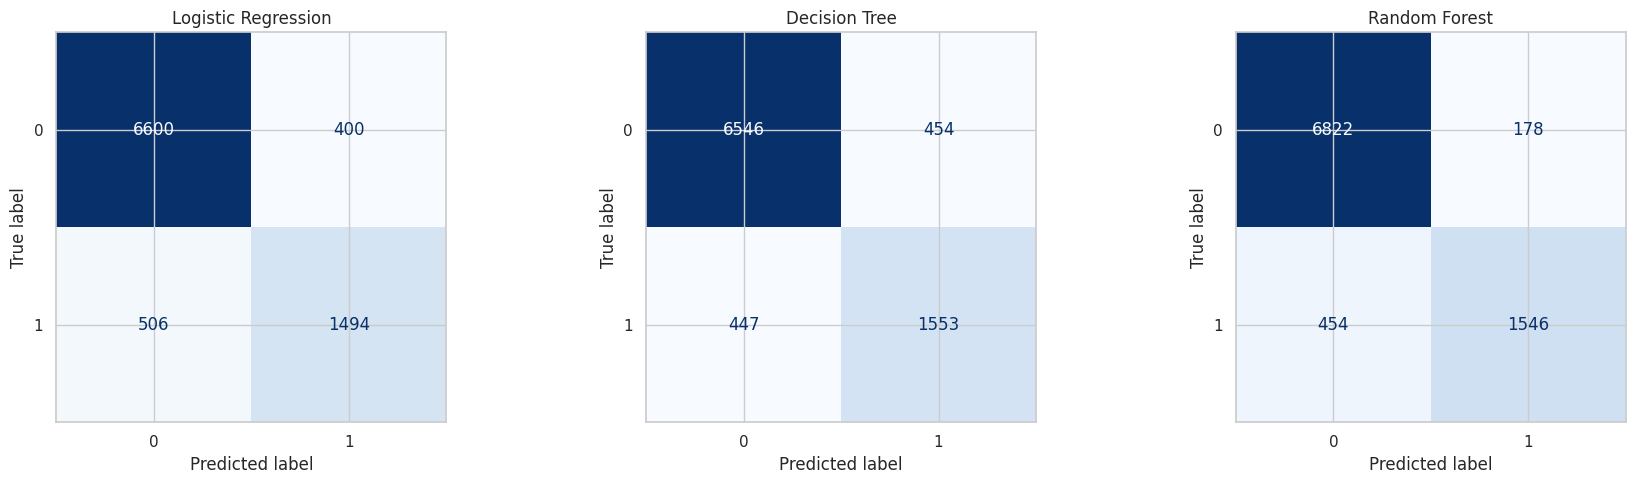

In [52]:
# Confusion Matrix

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, name in zip(axes, trained_models.keys()):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name]["y_pred"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

## Insight

Confusion Matrix menunjukkan jumlah prediksi yang benar maupun salah pada masing-masing kelas.

Pada kasus persetujuan pinjaman, **False Positive** (pinjaman disetujui padahal seharusnya ditolak) berpotensi meningkatkan risiko kredit macet. Sebaliknya, **False Negative** (pinjaman ditolak padahal sebenarnya layak) dapat menyebabkan hilangnya peluang bisnis. Oleh karena itu, keseimbangan antara Precision dan Recall menjadi aspek penting dalam memilih model terbaik.

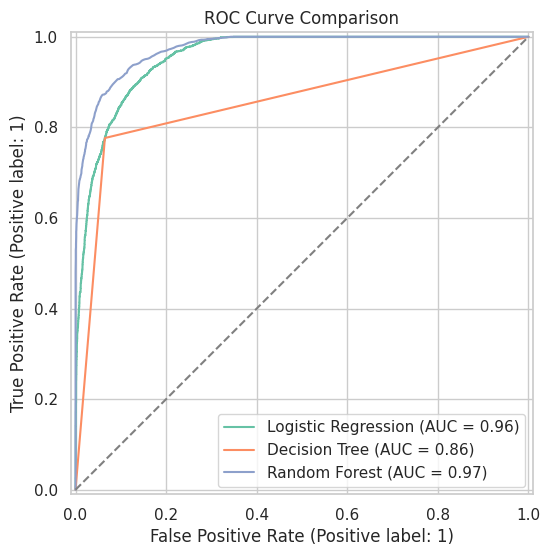

In [53]:
# ROC Curve

plt.figure(figsize=(8,6))

for name in trained_models.keys():

    RocCurveDisplay.from_predictions(
        y_test,
        predictions[name]["y_prob"],
        name=name,
        ax=plt.gca()
    )

plt.plot([0,1], [0,1], '--', color='gray')

plt.title("ROC Curve Comparison")

plt.show()

In [54]:
# Best Model

best_model = evaluation_df.iloc[0]

print("Best Model")
print("-"*40)

print(best_model)

Best Model
----------------------------------------
Model        Random Forest
Accuracy              0.93
Precision             0.90
Recall                0.77
F1-Score              0.83
ROC-AUC               0.97
Name: 0, dtype: object


💡 Insight

Model terbaik dipilih berdasarkan kombinasi beberapa metrik evaluasi, terutama **ROC-AUC** dan **F1-Score**, karena kedua metrik tersebut memberikan gambaran yang lebih komprehensif terhadap performa model pada dataset dengan distribusi kelas yang tidak seimbang.

Pemilihan model tidak hanya mempertimbangkan tingkat akurasi, tetapi juga kemampuan model dalam membedakan peminjam yang layak dan tidak layak memperoleh pinjaman.

# 💡 Business Insight

Berdasarkan hasil Exploratory Data Analysis (EDA) dan evaluasi model Machine Learning, diperoleh beberapa insight yang dapat mendukung proses pengambilan keputusan pada institusi keuangan.

### 1. Profil Peminjam

Analisis menunjukkan bahwa karakteristik demografi, kondisi finansial, dan riwayat kredit memiliki pengaruh terhadap peluang persetujuan pinjaman.

Fitur seperti pendapatan, jumlah pinjaman, skor kredit, serta riwayat gagal bayar menjadi indikator penting dalam proses evaluasi kredit.

---

### 2. Model sebagai Decision Support System

Model Machine Learning tidak dimaksudkan untuk menggantikan analis kredit, tetapi berfungsi sebagai **Decision Support System** yang membantu proses screening awal sehingga keputusan dapat diambil dengan lebih cepat dan konsisten.

---

### 3. Efisiensi Proses Persetujuan

Dengan adanya model prediksi, institusi keuangan dapat:

- Mempercepat proses evaluasi awal pengajuan pinjaman.
- Mengurangi beban kerja analis kredit.
- Meningkatkan konsistensi dalam proses penilaian.
- Mengurangi risiko pemberian pinjaman kepada peminjam berisiko tinggi.

---

### 4. Potensi Pengembangan

Model masih dapat ditingkatkan melalui:

- Hyperparameter Tuning
- Cross Validation
- Penambahan data historis
- Penggunaan algoritma ensemble lain seperti XGBoost atau LightGBM
- Deployment sebagai sistem prediksi berbasis web

# 📌 Conclusion

Project ini berhasil membangun model **Machine Learning Classification** untuk memprediksi status persetujuan pinjaman menggunakan **Loan Approval Classification Dataset**.

Tahapan proyek mencakup proses **Data Understanding**, **Exploratory Data Analysis**, **Data Cleaning**, **Feature Engineering**, **Data Preprocessing**, hingga pembangunan dan evaluasi beberapa algoritma Machine Learning.

Berdasarkan hasil evaluasi, model dengan performa terbaik dipilih menggunakan kombinasi metrik **ROC-AUC**, **F1-Score**, dan **Accuracy**, sehingga menghasilkan evaluasi yang lebih komprehensif dibandingkan hanya menggunakan accuracy.

Model yang dihasilkan berpotensi dimanfaatkan sebagai **Decision Support System** untuk membantu proses screening awal calon peminjam, sehingga proses persetujuan pinjaman dapat menjadi lebih cepat, konsisten, dan efisien.

Ke depan, performa model masih dapat ditingkatkan melalui proses **hyperparameter tuning**, **cross validation**, penggunaan algoritma ensemble yang lebih kompleks, serta deployment ke dalam aplikasi yang dapat digunakan oleh pengguna akhir.